## View Colored Parametric Map from QuantUS Workflow

This colored parametric map uses a pre-defined colormap to visualize the numerical values of a parametric map.

In the section after this, we will view the numerical values behind the colored parametric map, which can
also be used to make a new visualization with a different colormap.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

### Load single patient data (P34V1)

In [ ]:
colored_paramap_path = '/Users/luoweichen/Documents/2024/UCSD/IUS2025/IUS_3DCEUS/P34V1/AUC_TIC_numerical.npy'
im_path = '/Users/luoweichen/Documents/2024/UCSD/IUS2025/IUS_3DCEUS/P34V1/image.npy'
seg_path = '/Users/luoweichen/Documents/2024/UCSD/IUS2025/IUS_3DCEUS/P34V1/segmentation.npy'
numerical_paramap_path = '/Users/luoweichen/Documents/2024/UCSD/IUS2025/IUS_3DCEUS/P34V1/PE_TIC_numerical.npy'
pixdims = np.load('/Users/luoweichen/Documents/2024/UCSD/IUS2025/IUS_3DCEUS/P34V1/pix_dims.npy')

In [ ]:
colored_paramap = np.load(colored_paramap_path)
im = np.load(im_path)
seg = np.load(seg_path)

In [ ]:
colored_paramap.shape, im.shape, seg.shape

### Visualize colored paramap overlay on B-mode

In [ ]:
ax_frame = 29
frame = 10

plt.imshow(np.rot90(im[:, :, ax_frame, frame], k=3), cmap='gray', aspect='auto')
plt.imshow(np.rot90(colored_paramap[:, :, ax_frame], k=3), cmap='magma', alpha=0.9, aspect='auto')

## View Numerical Values Behind the Colored Parametric Map

In [ ]:
numerical_paramap = np.load(numerical_paramap_path)

In [ ]:
numerical_paramap.shape, colored_paramap.shape

In [ ]:
np.nanmax(numerical_paramap), np.nanmin(numerical_paramap)

### Visualize numerical paramap overlay

In [ ]:
ax_frame = 29  # Axial slice index
frame = 20

plt.imshow(np.rot90(im[:, :, ax_frame, frame], k=3), cmap='gray', aspect='auto')
plt.imshow(np.rot90(numerical_paramap[:, :, ax_frame], k=3), cmap='magma', alpha=0.9, aspect='auto')

### Single slice statistics and visualization

Extract a Y-Z slice at a given X index and compute nonzero pixel statistics.

In [ ]:
# numerical_paramap shape is [Y, Z, X]; x_i is the index along axis 2
x_i = 30

# Extract Y-Z slice at X = x_i
slice_x = numerical_paramap[:, :, x_i]  # shape: (Y, Z)

# Nonzero pixel statistics
nonzero_pixels = slice_x[slice_x > 0]
slice_mean_nonzero = np.mean(nonzero_pixels) if nonzero_pixels.size > 0 else 0.0
slice_area_nonzero = nonzero_pixels.size

print(f"[X={x_i}] Nonzero mean = {slice_mean_nonzero:.4f}, Nonzero area = {slice_area_nonzero} pixels")

In [ ]:
# Plot the slice (rot90 k=3 = clockwise 90 degrees)
plt.figure(figsize=(6, 6))
img = plt.imshow(np.rot90(slice_x, k=3), cmap='magma', origin='upper', aspect='auto')
plt.colorbar(img, label="Pixel Value")
plt.title(f"numerical_paramap @ X={x_i}\nNonzero mean={slice_mean_nonzero:.2f}, Nonzero area={slice_area_nonzero}")
plt.xlabel("Axis (rotated)")
plt.ylabel("Axis (rotated)")
plt.tight_layout()
plt.show()

---
## Batch V1 vs V2 Comparison Across Patients

Compare PE and log(AUC) parametric maps between Visit 1 and Visit 2 for each patient.

### Parameters

In [ ]:
from pathlib import Path
from itertools import permutations

ROOT = "/Users/samantha/Desktop/tul/china_data_paramaps"
PATIENT_IDS = ["P2", "P3", "P9", "P11", "P21", "P25", "P26", "P27", "P29", "P34", "P35", "P36", "P37", "P39"]

IMG_FNAME = "image.npy"              # [Y, Z, X, T]
PE_FNAME  = "PE_full_TIC_numerical.npy"   # 3D paramap
AUC_FNAME = "AUC_full_TIC_numerical.npy"  # 3D paramap
PIX_FNAME = "pix_dims.npy"
FRAME = 20                           # B-mode time point

# Percentile clipping bounds for log(AUC) visualization
AUC_LOG_VIZ_P_LOW  = 1
AUC_LOG_VIZ_P_HIGH = 99.9
WINSORIZE_FOR_STATS = False

### Helper functions

In [11]:
def load_np(base_dir, fname):
    """Load a .npy file from base_dir."""
    return np.load(str(Path(base_dir) / fname))


def load_pixdims(base_dir):
    """Load pixel dimensions, returning None if unavailable."""
    p = Path(base_dir) / PIX_FNAME
    return np.load(str(p)) if p.exists() else None

In [12]:
def align_pm_to_im(pm, im):
    """Transpose 3D paramap to match image spatial axes (Y, Z, X)."""
    target = im.shape[:3]
    for p in permutations(range(3)):
        if tuple(pm.shape[i] for i in p) == target:
            return np.transpose(pm, p), p
    raise ValueError(f"Cannot align paramap {pm.shape} to image {target}")

In [13]:
def best_x_slice(pm):
    """Find X index (axis 2) with the most finite, positive pixels."""
    counts = np.array([
        np.sum(np.isfinite(pm[:, :, xi]) & (pm[:, :, xi] > 0))
        for xi in range(pm.shape[2])
    ])
    return int(np.argmax(counts)), counts


def nonzero_stats(arr2d):
    """Compute mean, pixel count, and fill ratio for finite positive pixels."""
    mask = np.isfinite(arr2d) & (arr2d > 0)
    vals = arr2d[mask]
    if vals.size == 0:
        return 0.0, 0, 0.0
    return float(vals.mean()), int(vals.size), vals.size / mask.size


def pixels_to_mm2(count, pixdims):
    """Convert pixel count to mm^2 using pixel spacing."""
    if pixdims is None:
        return None
    return count * float(pixdims[0]) * float(pixdims[1])


def pct_change(new, base):
    """Percent change from base to new."""
    if base is None or base == 0 or (isinstance(base, float) and np.isnan(base)):
        return np.nan
    return 100.0 * (new - base) / base

In [14]:
def clip_percentile(arr, p_low=None, p_high=99):
    """Clip finite values to given percentiles (for visualization only)."""
    s = arr.astype(float).copy()
    m = np.isfinite(s)
    if not m.any():
        return s
    if p_low is not None:
        lo = np.percentile(s[m], p_low)
        s[m & (s < lo)] = lo
    if p_high is not None:
        hi = np.percentile(s[m], p_high)
        s[m & (s > hi)] = hi
    return s


def finite_minmax(arr):
    """Min and max of finite values."""
    m = np.isfinite(arr)
    if not m.any():
        return 0.0, 1.0
    return float(np.nanmin(arr[m])), float(np.nanmax(arr[m]))


def style_colorbar(cbar, label):
    """Style a colorbar for dark backgrounds."""
    cbar.ax.set_facecolor("black")
    cbar.outline.set_edgecolor("white")
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.get_yticklabels(), color="white")
    cbar.set_label(label, fontsize=8, color="white")

### Processing functions

In [15]:
def process_pe(base_dir, frame=FRAME):
    """Load image + PE paramap, align, pick best X slice, compute stats."""
    im = load_np(base_dir, IMG_FNAME)
    pe = load_np(base_dir, PE_FNAME)
    pe_aligned, perm = align_pm_to_im(pe, im)
    x_i, counts = best_x_slice(pe_aligned)
    mean, area_px, fill = nonzero_stats(pe_aligned[:, :, x_i].astype(float))
    area_mm2 = pixels_to_mm2(area_px, load_pixdims(base_dir))
    return {
        "im": im, "pe": pe_aligned, "perm": perm,
        "x_i": x_i, "counts": counts,
        "mean": mean, "area_px": area_px, "fill": fill,
        "area_mm2": area_mm2, "frame": frame,
    }

In [16]:
def process_log_auc(base_dir, im, x_i, frame=FRAME):
    """Load AUC paramap, align, compute log(AUC) stats at the given X slice."""
    auc_raw = load_np(base_dir, AUC_FNAME)
    auc_aligned, perm = align_pm_to_im(auc_raw, im)
    s = auc_aligned[:, :, x_i].astype(float)

    # Compute log(AUC) for positive finite pixels
    mask = np.isfinite(s) & (s > 0)
    log_slice = np.full_like(s, np.nan)
    log_slice[mask] = np.log(s[mask])

    # Statistics (optionally winsorized)
    stats = clip_percentile(log_slice, AUC_LOG_VIZ_P_LOW, AUC_LOG_VIZ_P_HIGH) if WINSORIZE_FOR_STATS else log_slice
    if np.isfinite(stats).any():
        log_mean = float(np.nanmean(stats))
        geom_mean = float(np.exp(log_mean))
        area_px = int(np.isfinite(stats).sum())
        fill = area_px / stats.size
    else:
        geom_mean, area_px, fill = 0.0, 0, 0.0

    # Clipped version for visualization
    viz_slice = clip_percentile(log_slice, AUC_LOG_VIZ_P_LOW, AUC_LOG_VIZ_P_HIGH)

    return {
        "auc": auc_aligned, "perm": perm, "log_slice": log_slice,
        "log_slice_viz": viz_slice, "geom_mean": geom_mean,
        "area_px": area_px, "fill": fill, "frame": frame,
    }

In [17]:
def compare_v1_v2(patient_id):
    """Compare PE and log(AUC) between V1 and V2 for one patient."""
    v1_dir = f"{ROOT}/{patient_id}V1"
    v2_dir = f"{ROOT}/{patient_id}V2"
    if not Path(v1_dir).exists() or not Path(v2_dir).exists():
        print(f"[SKIP] {patient_id}: directory not found")
        return None

    v1PE = process_pe(v1_dir)
    v2PE = process_pe(v2_dir)
    v1AUC = process_log_auc(v1_dir, v1PE["im"], v1PE["x_i"])
    v2AUC = process_log_auc(v2_dir, v2PE["im"], v2PE["x_i"])

    # Compute percent changes
    delta_pe = {
        "mean_pct": pct_change(v2PE["mean"], v1PE["mean"]),
        "area_px_pct": pct_change(v2PE["area_px"], v1PE["area_px"]),
        "fill_pct": pct_change(v2PE["fill"], v1PE["fill"]),
        "area_mm2_pct": (
            pct_change(v2PE["area_mm2"], v1PE["area_mm2"])
            if v1PE["area_mm2"] is not None and v2PE["area_mm2"] is not None
            else None
        ),
    }
    delta_auc = {
        "geom_mean_pct": pct_change(v2AUC["geom_mean"], v1AUC["geom_mean"]),
        "area_px_pct": pct_change(v2AUC["area_px"], v1AUC["area_px"]),
        "fill_pct": pct_change(v2AUC["fill"], v1AUC["fill"]),
    }

    return {
        "patient": patient_id,
        "V1": {"PE": v1PE, "AUC": v1AUC},
        "V2": {"PE": v2PE, "AUC": v2AUC},
        "delta": {"PE": delta_pe, "AUC": delta_auc},
    }

### Run batch comparison

In [18]:
import numpy as np

results = []
for pid in PATIENT_IDS:
    print(f"Processing {pid}...", end=" ", flush=True)
    out = compare_v1_v2(pid)
    if out is not None:
        results.append(out)
        print("done")
    else:
        print("skipped (missing directory)")
print(f"\nCompleted {len(results)}/{len(PATIENT_IDS)} patients.")

Processing P2... done
Processing P3... done
Processing P9... done
Processing P11... done
Processing P21... done
Processing P25... done
Processing P26... done
Processing P27... done
Processing P29... done
Processing P34... done
Processing P35... done
Processing P36... done
Processing P37... done
Processing P39... done

Completed 14/14 patients.


### Print detailed per-patient results

In [19]:
for r in results:
    p = r["patient"]
    print(f"\n=== {p}: PE & log(AUC) ===")
    for visit in ["V1", "V2"]:
        d = r[visit]["PE"]
        area_str = f", area(mm2)={d['area_mm2']:.2f}" if d["area_mm2"] is not None else ""
        print(f"  {p}{visit}-PE: X={d['x_i']} | mean={d['mean']:.4f}, area(px)={d['area_px']:,}, fill={d['fill']:.3f}{area_str}")
    for visit in ["V1", "V2"]:
        a = r[visit]["AUC"]
        pe = r[visit]["PE"]
        print(f"  {p}{visit}-AUC: X={pe['x_i']} | geom_mean={a['geom_mean']:.6f}, area(px)={a['area_px']:,}, fill={a['fill']:.3f}")

    dpe = r["delta"]["PE"]
    dau = r["delta"]["AUC"]
    mm2_str = f" | area(mm2) {dpe['area_mm2_pct']:.2f}%" if dpe["area_mm2_pct"] is not None else ""
    print(f"  Delta PE:  mean {dpe['mean_pct']:.2f}% | area(px) {dpe['area_px_pct']:.2f}% | fill {dpe['fill_pct']:.2f}%{mm2_str}")
    print(f"  Delta AUC: geom-mean {dau['geom_mean_pct']:.2f}% | area(px) {dau['area_px_pct']:.2f}% | fill {dau['fill_pct']:.2f}%")


=== P2: PE & log(AUC) ===
  P2V1-PE: X=45 | mean=1.0025, area(px)=2,651, fill=0.059, area(mm2)=1210.93
  P2V2-PE: X=47 | mean=0.9341, area(px)=3,131, fill=0.074, area(mm2)=1484.72
  P2V1-AUC: X=45 | geom_mean=358.194800, area(px)=2,651, fill=0.059
  P2V2-AUC: X=47 | geom_mean=231.144084, area(px)=3,131, fill=0.074
  Delta PE:  mean -6.82% | area(px) 18.11% | fill 26.54% | area(mm2) 22.61%
  Delta AUC: geom-mean -35.47% | area(px) 18.11% | fill 26.54%

=== P3: PE & log(AUC) ===
  P3V1-PE: X=47 | mean=1.0442, area(px)=3,722, fill=0.093, area(mm2)=1321.60
  P3V2-PE: X=18 | mean=0.9724, area(px)=5,653, fill=0.141, area(mm2)=2007.25
  P3V1-AUC: X=47 | geom_mean=486.497974, area(px)=3,722, fill=0.093
  P3V2-AUC: X=18 | geom_mean=310.700601, area(px)=5,653, fill=0.141
  Delta PE:  mean -6.87% | area(px) 51.88% | fill 51.88% | area(mm2) 51.88%
  Delta AUC: geom-mean -36.14% | area(px) 51.88% | fill 51.88%

=== P9: PE & log(AUC) ===
  P9V1-PE: X=39 | mean=1.0119, area(px)=6,986, fill=0.095, ar

### Grid plot: all patients (PE V1, PE V2, log(AUC) V1, log(AUC) V2)

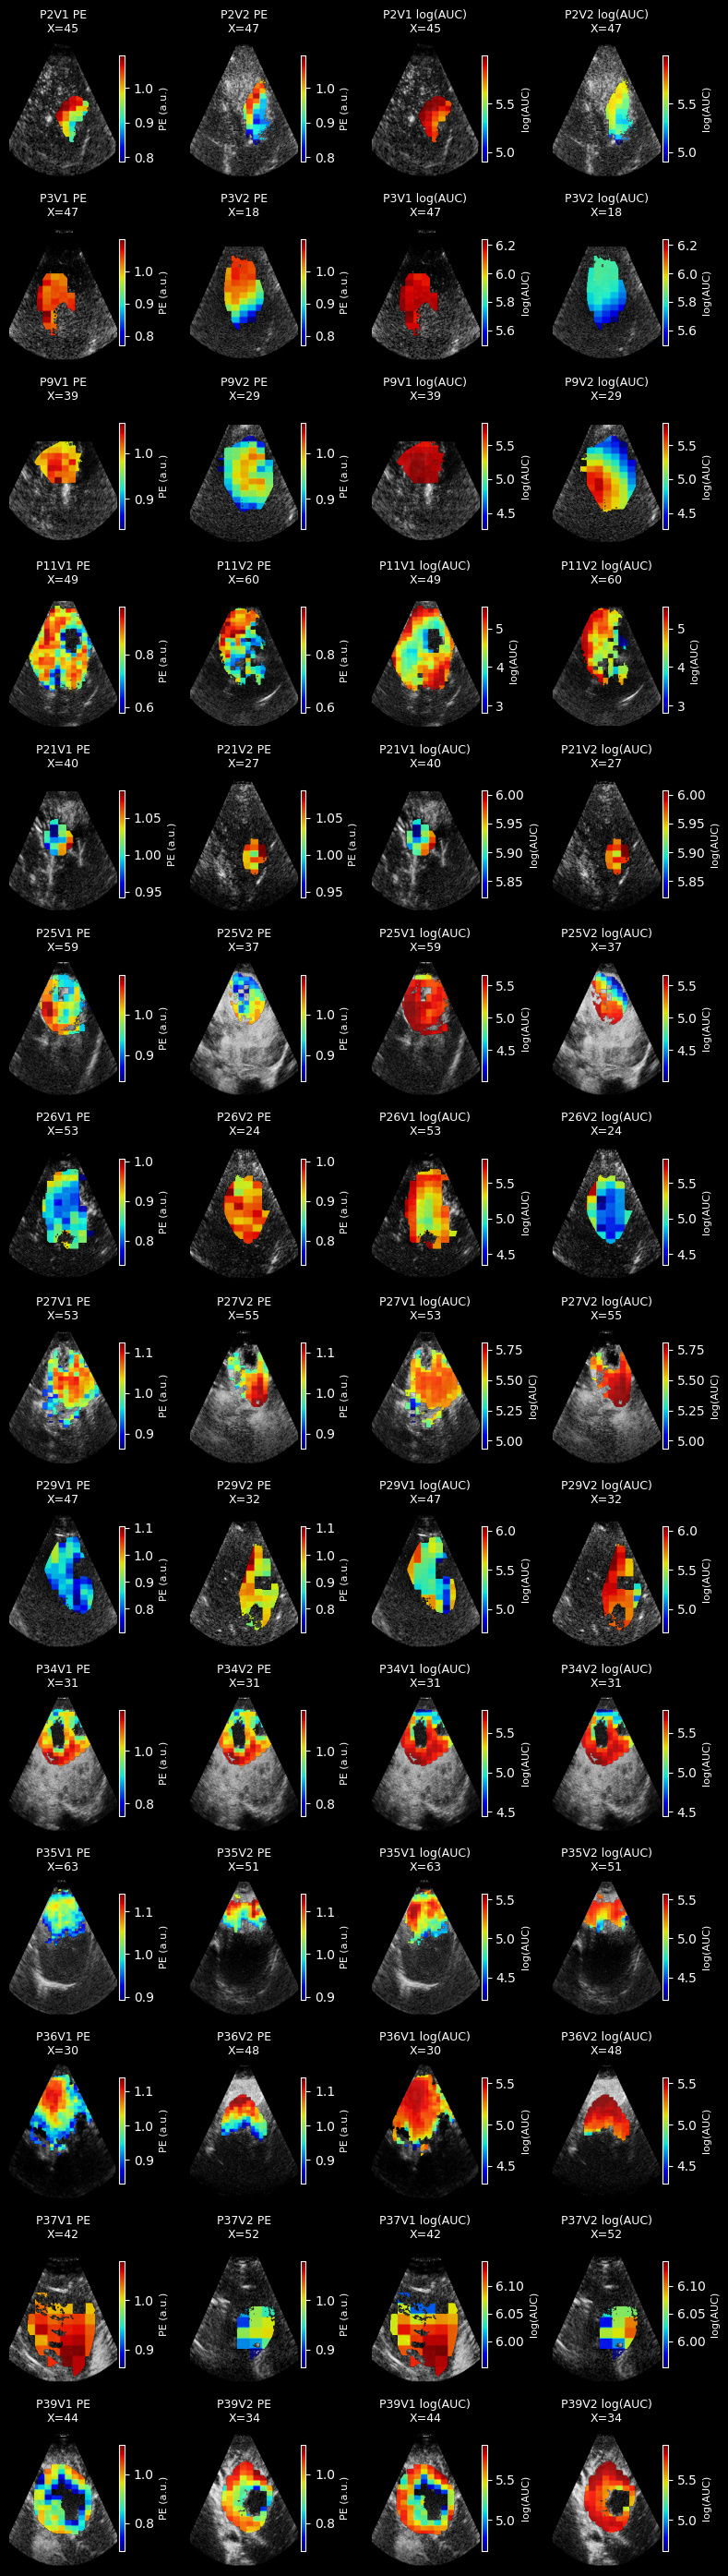

In [22]:
import matplotlib.pyplot as plt
n = len(results)
if n > 0:
    fig, axes = plt.subplots(nrows=n, ncols=4, figsize=(8, 2 * n))
    if n == 1:
        axes = np.array([axes])

    for row, r in enumerate(results):
        p = r["patient"]
        v1PE, v2PE = r["V1"]["PE"], r["V2"]["PE"]
        v1AUC, v2AUC = r["V1"]["AUC"], r["V2"]["AUC"]

        # Shared color scale for PE
        pe_v1_vis = clip_percentile(v1PE['pe'][:, :, v1PE['x_i']], p_high=99)
        pe_v2_vis = clip_percentile(v2PE['pe'][:, :, v2PE['x_i']], p_high=99)
        pe_vmin = min(finite_minmax(pe_v1_vis)[0], finite_minmax(pe_v2_vis)[0])
        pe_vmax = max(finite_minmax(pe_v1_vis)[1], finite_minmax(pe_v2_vis)[1])

        # Shared color scale for log(AUC)
        auc_vmin = min(finite_minmax(v1AUC['log_slice_viz'])[0], finite_minmax(v2AUC['log_slice_viz'])[0])
        auc_vmax = max(finite_minmax(v1AUC['log_slice_viz'])[1], finite_minmax(v2AUC['log_slice_viz'])[1])

        # Plot each column: PE V1, PE V2, AUC V1, AUC V2
        panels = [
            (v1PE, pe_v1_vis, pe_vmin, pe_vmax, f"{p}V1 PE\nX={v1PE['x_i']}", "PE (a.u.)"),
            (v2PE, pe_v2_vis, pe_vmin, pe_vmax, f"{p}V2 PE\nX={v2PE['x_i']}", "PE (a.u.)"),
            (v1PE, v1AUC['log_slice_viz'], auc_vmin, auc_vmax, f"{p}V1 log(AUC)\nX={v1PE['x_i']}", "log(AUC)"),
            (v2PE, v2AUC['log_slice_viz'], auc_vmin, auc_vmax, f"{p}V2 log(AUC)\nX={v2PE['x_i']}", "log(AUC)"),
        ]
        for col, (pe_data, overlay, vmin, vmax, title, cbar_label) in enumerate(panels):
            ax = axes[row, col]
            ax.imshow(np.rot90(pe_data['im'][:, :, pe_data['x_i'], pe_data['frame']], k=3), cmap='gray', aspect='auto')
            mappable = ax.imshow(np.rot90(overlay, k=3), cmap='jet', alpha=0.9, aspect='auto', vmin=vmin, vmax=vmax)
            ax.set_title(title, fontsize=9, color="white")
            ax.axis('off')
            style_colorbar(fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.02), cbar_label)

    fig.patch.set_facecolor("black")
    plt.tight_layout()
    plt.show()

### Summary table (V2 vs V1 percent changes)

In [15]:
print("==== Summary (V2 vs V1) ====")
for r in results:
    p = r["patient"]
    dpe = r["delta"]["PE"]
    dau = r["delta"]["AUC"]
    mm2_str = f", area(mm2) {dpe['area_mm2_pct']:.2f}%" if dpe["area_mm2_pct"] is not None else ""
    print(f"{p} | PE: mean {dpe['mean_pct']:.2f}%, area(px) {dpe['area_px_pct']:.2f}%, fill {dpe['fill_pct']:.2f}%{mm2_str}")
    print(f"   | AUC(log): geom-mean {dau['geom_mean_pct']:.2f}%, area(px) {dau['area_px_pct']:.2f}%, fill {dau['fill_pct']:.2f}%")

==== Summary (V2 vs V1) ====
P2 | PE: mean -6.82%, area(px) 18.11%, fill 26.54%, area(mm2) 22.61%
   | AUC(log): geom-mean -35.47%, area(px) 18.11%, fill 26.54%
P25 | PE: mean -3.62%, area(px) -41.00%, fill -41.00%, area(mm2) -68.61%
   | AUC(log): geom-mean -36.70%, area(px) -41.00%, fill -41.00%
P34 | PE: mean 0.00%, area(px) 0.00%, fill 0.00%, area(mm2) 0.00%
   | AUC(log): geom-mean 0.00%, area(px) 0.00%, fill 0.00%


---
## Single Patient PE Pair Plot

Compare V1 vs V2 PE paramaps side-by-side for a single patient.

In [16]:
def plot_pair_pe(patient_id, cmap='magma', frame=FRAME):
    """Plot V1 vs V2 PE paramaps side-by-side for one patient."""
    v1_dir = f"{ROOT}/{patient_id}V1"
    v2_dir = f"{ROOT}/{patient_id}V2"
    if not Path(v1_dir).exists() or not Path(v2_dir).exists():
        print(f"[SKIP] {patient_id}: directory not found")
        return

    v1 = process_pe(v1_dir, frame=frame)
    v2 = process_pe(v2_dir, frame=frame)

    # Shared color scale from p99-clipped slices
    v1_vis = clip_percentile(v1['pe'][:, :, v1['x_i']], p_high=99)
    v2_vis = clip_percentile(v2['pe'][:, :, v2['x_i']], p_high=99)
    vmin = min(finite_minmax(v1_vis)[0], finite_minmax(v2_vis)[0])
    vmax = max(finite_minmax(v1_vis)[1], finite_minmax(v2_vis)[1])

    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    fig.patch.set_facecolor("black")

    for ax, data, vis, label in [
        (axes[0], v1, v1_vis, f"{patient_id}V1 PE | X={v1['x_i']}"),
        (axes[1], v2, v2_vis, f"{patient_id}V2 PE | X={v2['x_i']}"),
    ]:
        ax.imshow(np.rot90(data['im'][:, :, data['x_i'], data['frame']], k=3), cmap='gray', aspect='auto')
        mappable = ax.imshow(np.rot90(vis, k=3), cmap=cmap, alpha=0.9, aspect='auto', vmin=vmin, vmax=vmax)
        ax.set_title(label, fontsize=10, color="white")
        ax.axis('off')
        style_colorbar(fig.colorbar(mappable, ax=ax, fraction=0.046, pad=0.02), "PE (a.u.)")

    plt.tight_layout()
    plt.show()

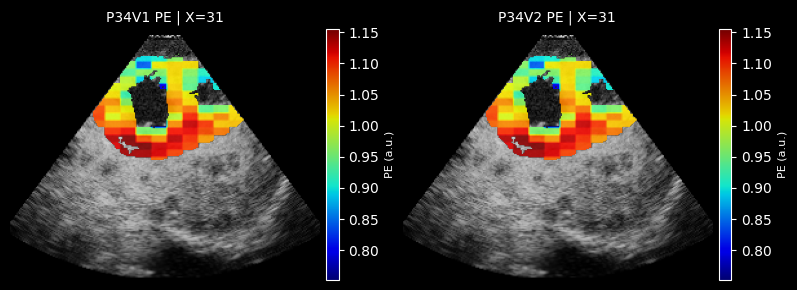

In [17]:
plot_pair_pe("P34", cmap="jet", frame=20)